# Terraform — Complete Learning Guide



> A practical, end-to-end learning path for Terraform with a strong focus on AWS, DevOps, Infrastructure as Code, CI/CD, reusable modules, state management, security, and real-world projects.

---

# Table of Contents

1. [What Is Terraform?](#1-what-is-terraform)
2. [Infrastructure as Code](#2-infrastructure-as-code)
3. [Terraform Architecture and Workflow](#3-terraform-architecture-and-workflow)
4. [Installation and Environment Setup](#4-installation-and-environment-setup)
5. [HCL Fundamentals](#5-hcl-fundamentals)
6. [Providers](#6-providers)
7. [Resources](#7-resources)
8. [Variables](#8-variables)
9. [Outputs](#9-outputs)
10. [Locals](#10-locals)
11. [Data Sources](#11-data-sources)
12. [Terraform Commands](#12-terraform-commands)
13. [Terraform State](#13-terraform-state)
14. [Remote State and State Locking](#14-remote-state-and-state-locking)
15. [Resource Dependencies](#15-resource-dependencies)
16. [Meta-Arguments](#16-meta-arguments)
17. [Expressions, Functions, and Collections](#17-expressions-functions-and-collections)
18. [Dynamic Blocks](#18-dynamic-blocks)
19. [Provisioners](#19-provisioners)
20. [Terraform Modules](#20-terraform-modules)
21. [Terraform Workspaces](#21-terraform-workspaces)
22. [Lifecycle Management](#22-lifecycle-management)
23. [Importing Existing Infrastructure](#23-importing-existing-infrastructure)
24. [Managing Sensitive Data](#24-managing-sensitive-data)
25. [Terraform with AWS](#25-terraform-with-aws)
26. [AWS Networking Project](#26-aws-networking-project)
27. [AWS EC2 Project](#27-aws-ec2-project)
28. [AWS Load Balancer and Auto Scaling](#28-aws-load-balancer-and-auto-scaling)
29. [AWS RDS](#29-aws-rds)
30. [AWS S3](#30-aws-s3)
31. [AWS IAM](#31-aws-iam)
32. [Terraform and Docker](#32-terraform-and-docker)
33. [Terraform and Kubernetes](#33-terraform-and-kubernetes)
34. [Terraform in CI/CD](#34-terraform-in-cicd)
35. [Terraform with GitHub Actions](#35-terraform-with-github-actions)
36. [Repository Structure](#36-repository-structure)
37. [Testing and Validation](#37-testing-and-validation)
38. [Security Best Practices](#38-security-best-practices)
39. [Troubleshooting](#39-troubleshooting)
40. [Common Interview Questions](#40-common-interview-questions)
41. [Hands-On Projects](#41-hands-on-projects)
42. [Learning Roadmap](#42-learning-roadmap)
43. [Terraform Command Cheat Sheet](#43-terraform-command-cheat-sheet)
44. [Final Best Practices](#44-final-best-practices)

---


# 1. What Is Terraform?




Terraform is an **Infrastructure as Code (IaC)** tool created by HashiCorp.

It allows infrastructure to be defined using configuration files rather than manually creating resources through cloud consoles.

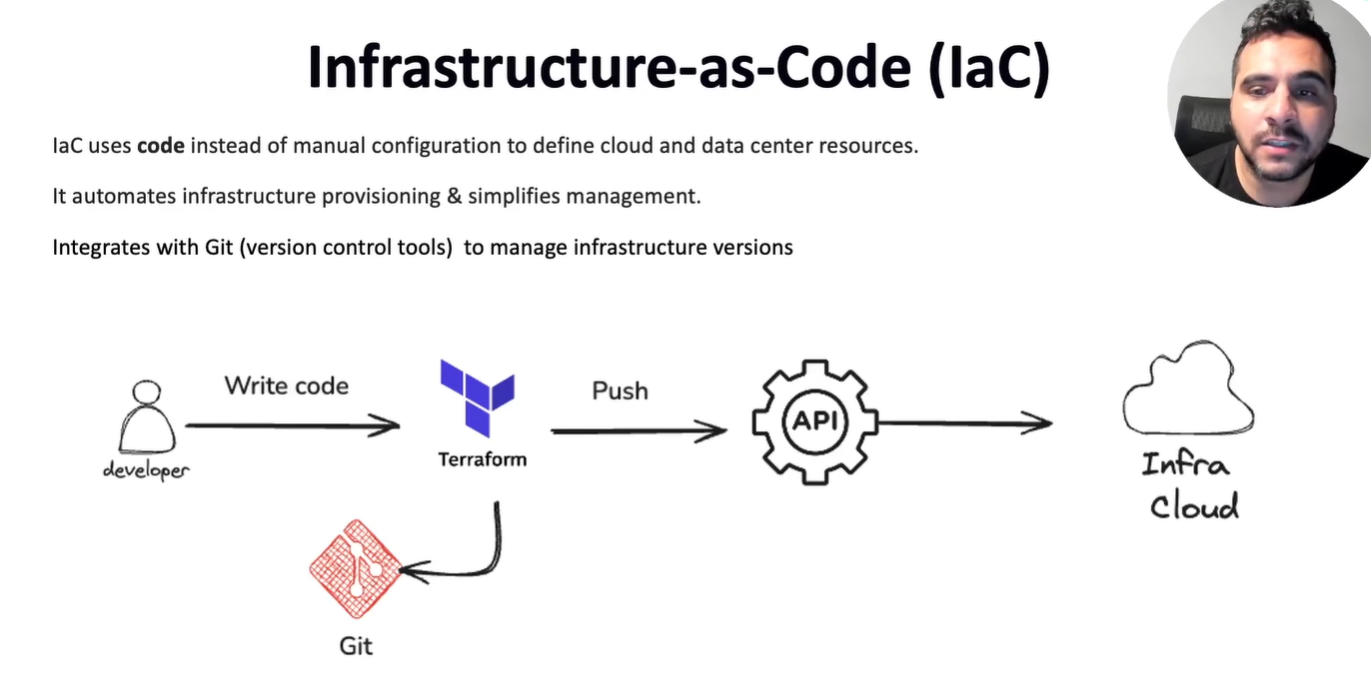

Terraform can manage infrastructure across providers such as:

- AWS
- Microsoft Azure
- Google Cloud
- Kubernetes
- Docker
- GitHub
- Cloudflare
- Datadog
- VMware
- many SaaS and infrastructure platforms

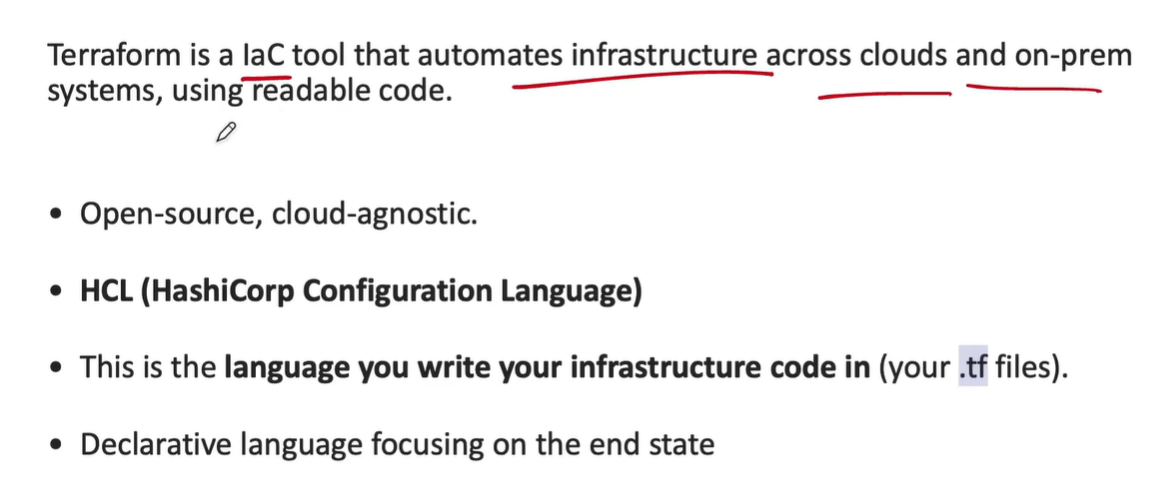


Instead of manually creating an EC2 instance from the AWS Console, you can describe it in code:

```hcl
resource "aws_instance" "web" {
  ami           = "ami-xxxxxxxxxxxxxxxxx"
  instance_type = "t3.micro"

  tags = {
    Name = "terraform-web"
  }
}
```

Terraform compares the configuration with the real infrastructure and calculates what needs to be created, changed, or removed.


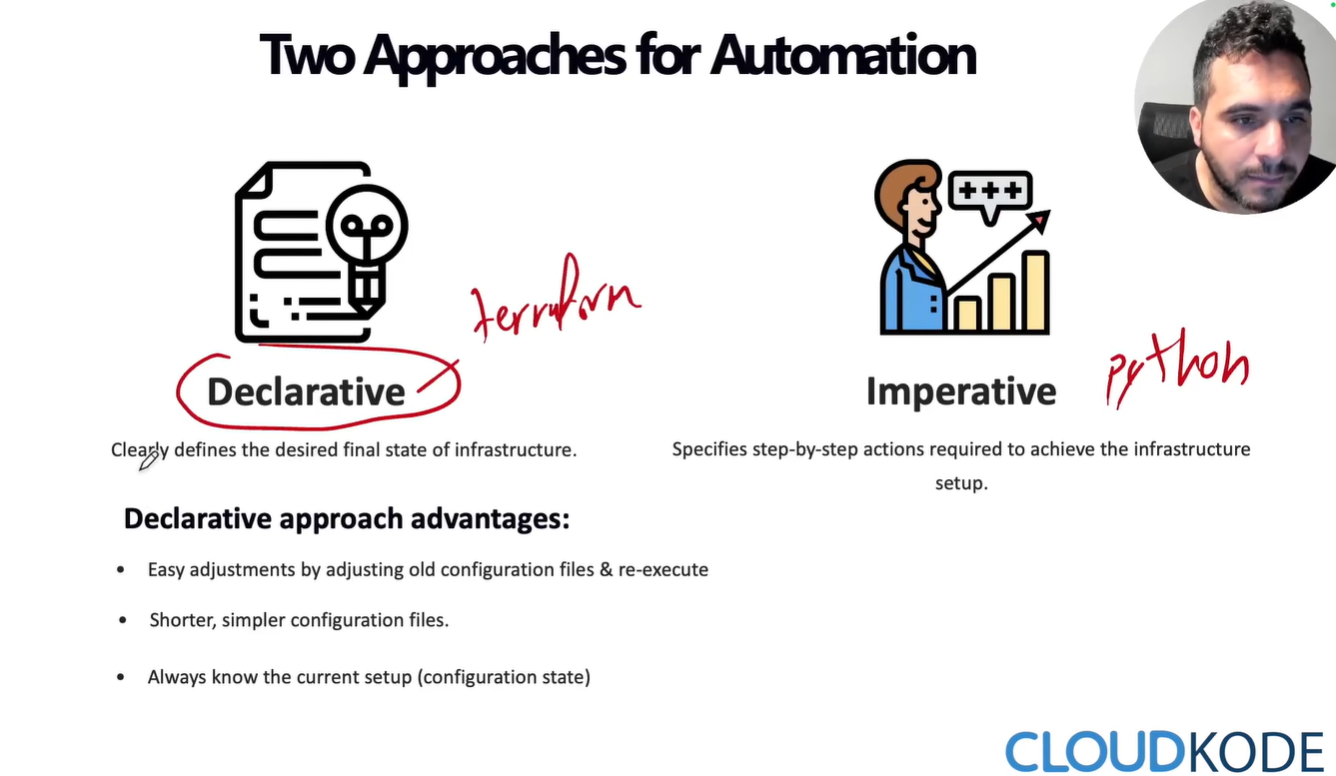

## Why Terraform Is Important

Terraform provides:

- Repeatability
- Version control
- Automation
- Standardization
- Faster infrastructure deployment
- Easier disaster recovery
- Consistent environments
- Reduced manual configuration
- Multi-cloud support



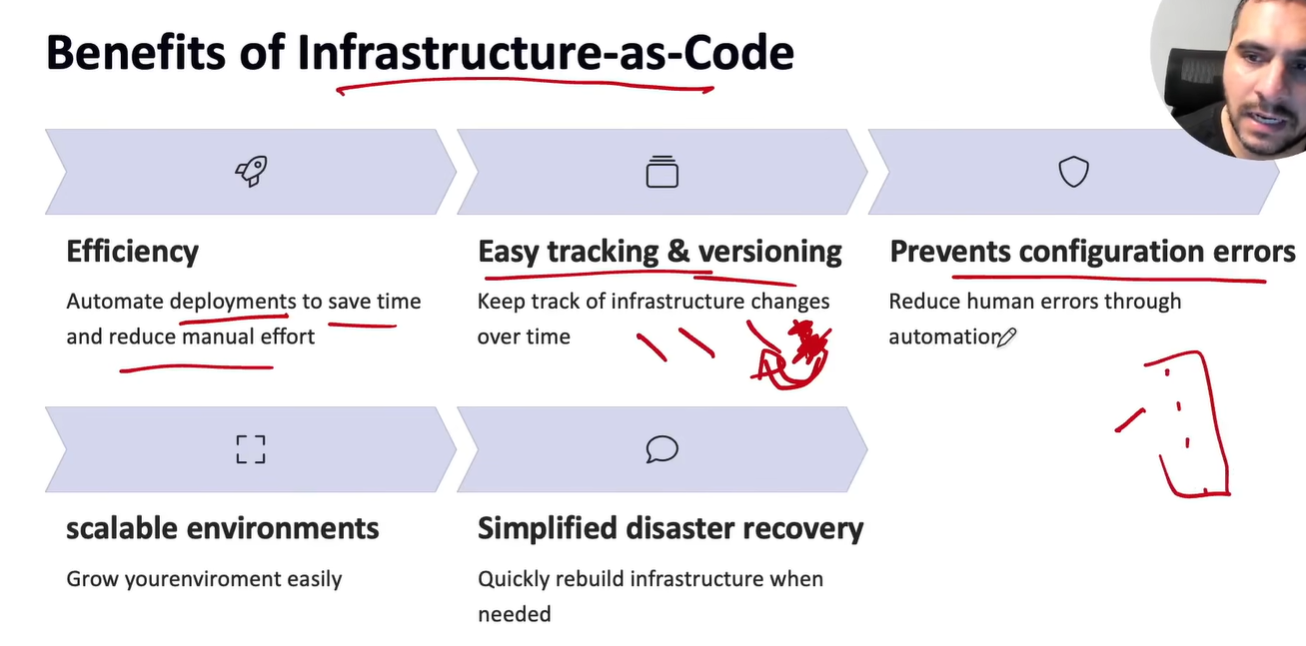


Terraform is commonly used by:

- DevOps Engineers
- Cloud Engineers
- Platform Engineers
- Site Reliability Engineers
- Infrastructure Engineers
- Backend Engineers
- Data Engineers
- AI Platform Engineers



## Mutable vs Immutable Infrastructure

Infrastructure can be managed using either a **mutable** or **immutable** approach.

| Type | Description | Examples |
|---|---|---|
| **Mutable Infrastructure** | Existing infrastructure is modified or updated in place. | Ansible, Puppet, Chef |
| **Immutable Infrastructure** | Existing infrastructure is replaced by a new version instead of being modified. | Docker, Kubernetes, Terraform |



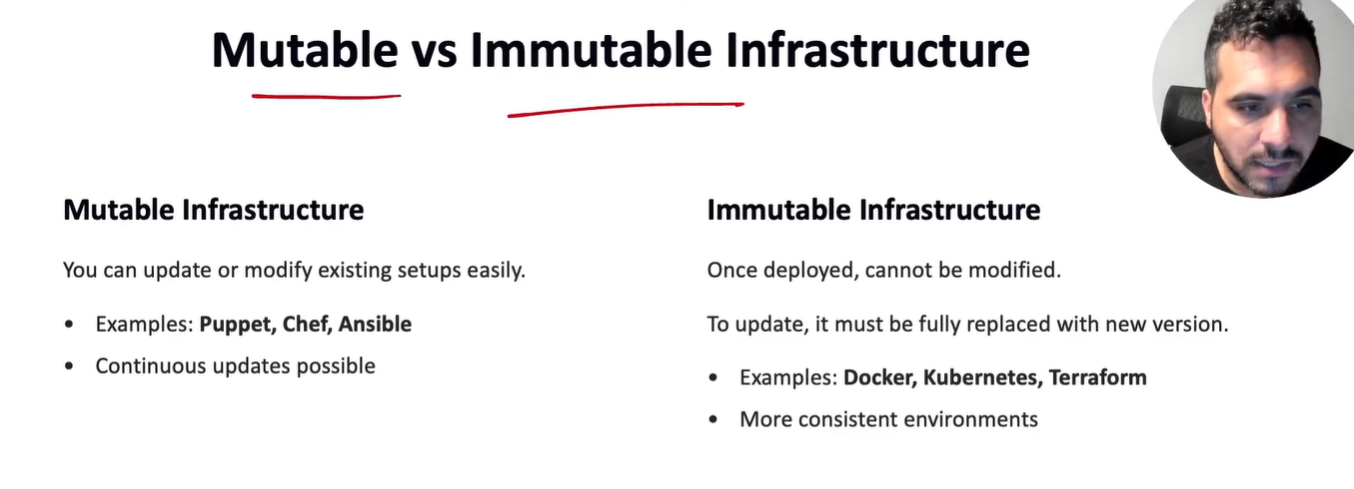


### Mutable Infrastructure

```text
Existing Server
      ↓
Apply Updates
      ↓
Same Server Continues Running
```

Existing servers can be modified continuously.

- Common with configuration-management tools.
- Can cause **configuration drift** over time.

### Immutable Infrastructure

```text
Old Infrastructure
       ↓
Create New Version
       ↓
Replace Old Version

```


Infrastructure is replaced instead of manually modified.

- Provides more consistent environments.
- Reduces configuration drift.
- Makes rollback easier.

> **Note:** Terraform supports immutable infrastructure patterns, but it is not strictly immutable. Depending on the resource and the changed attribute, Terraform may either **update the resource in place** or **destroy and recreate it**.



## Agent-Based vs Agentless Tools

Infrastructure automation tools can be classified as **agent-based** or **agentless** depending on how they communicate with managed systems.

| Type | Description | Examples |
|---|---|---|
| **Agent-Based** | Requires an agent to be installed on each managed machine. The agent communicates with a central server to receive configuration or instructions. | Puppet, Chef |
| **Agentless** | Does not require a dedicated agent on managed machines. It communicates using protocols or APIs such as SSH, WinRM, or HTTPS. | Ansible, Terraform |

### Agent-Based

```text
Central Server
      ↓
    Agent
      ↓
Managed Server
```

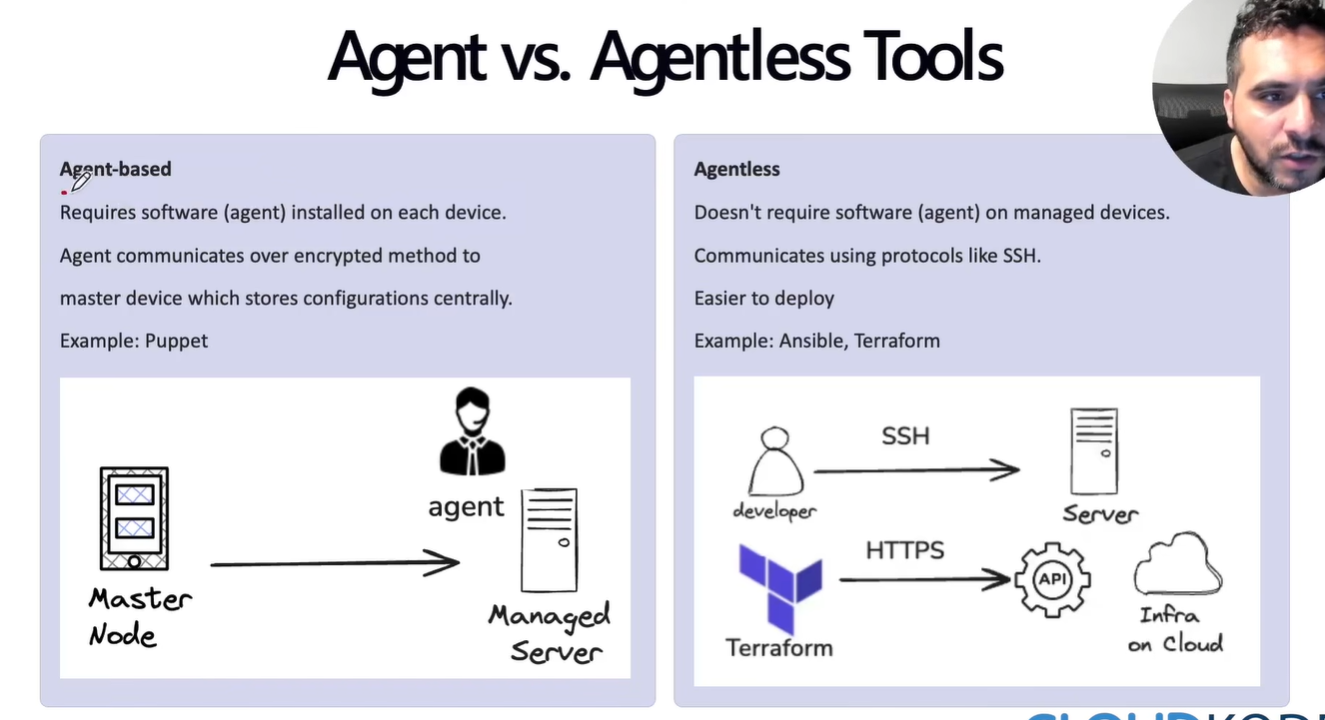

Requires software to be installed on managed systems.

- Agents communicate with a central management server.
- Useful for continuous configuration enforcement.
- Requires additional agent installation and maintenance.

### Agentless

```text
Ansible
   ↓ SSH / WinRM
Server

Terraform
   ↓ HTTPS / Cloud API
AWS / Azure / GCP
```

No dedicated management agent is required on the target resource.

- Easier to deploy and maintain.
- **Ansible** commonly connects to servers through **SSH** or **WinRM**.
- **Terraform** normally communicates directly with cloud/provider **APIs over HTTPS**.

> **Note:** Terraform is considered agentless because it does not require Terraform software to run on every managed cloud resource. Terraform runs from a workstation or CI/CD runner and communicates with providers such as AWS through their APIs.


---



# 2. Infrastructure as Code




Infrastructure as Code means defining infrastructure using code or configuration files.

Without IaC:

```text
Engineer
   ↓
AWS Console
   ↓
Click VPC
Click Subnet
Click EC2
Configure Security Group
Create Load Balancer
Create Database
```

With IaC:

```text
Terraform Configuration
        ↓
terraform plan
        ↓
terraform apply
        ↓
AWS Infrastructure
```

## Benefits

### Reproducibility

The same code can create the same infrastructure multiple times.

### Version Control

Terraform files can be stored in Git.

```bash
git add .
git commit -m "Add production VPC"
git push
```

### Automation

Terraform can run automatically from:

- GitHub Actions
- GitLab CI
- Jenkins
- Azure DevOps
- CircleCI

### Documentation

Terraform code also acts as infrastructure documentation.

### Disaster Recovery

If infrastructure is lost, the configuration can help recreate it.

### Popular Infrastructure as code tools

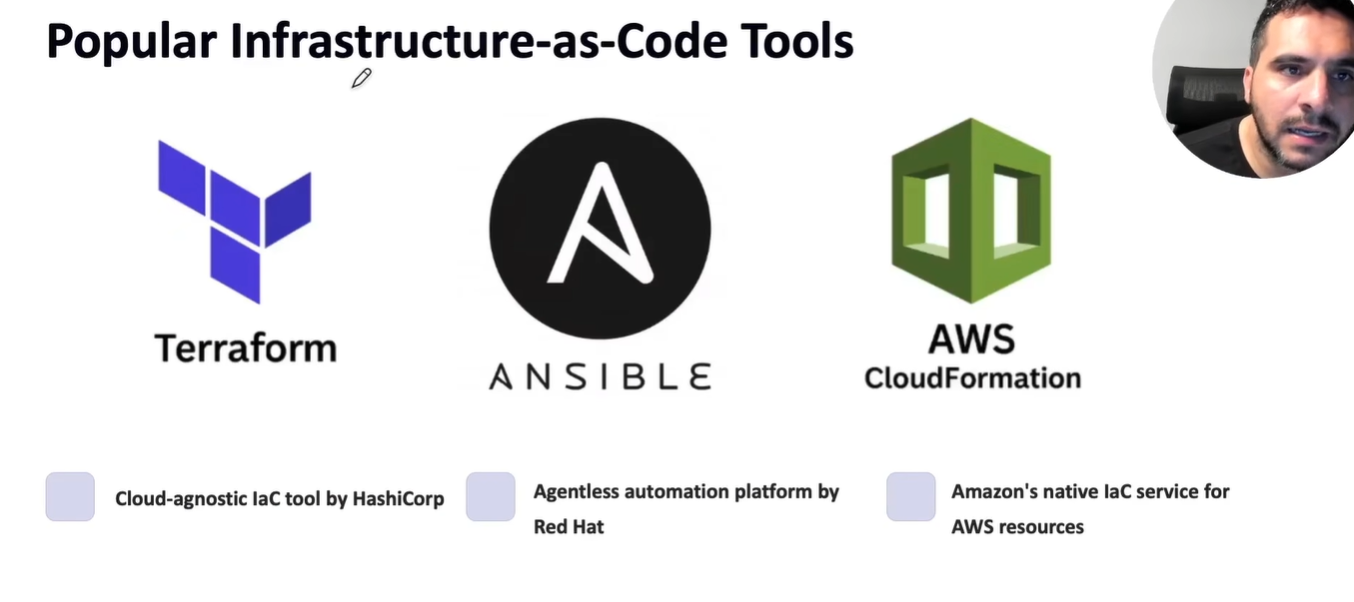


---


# 3. Terraform Architecture and Workflow




Terraform uses a declarative model.

You describe the **desired state**.

Example:

```hcl
resource "aws_instance" "app" {
  instance_type = "t3.micro"
}
```

Terraform determines how to reach that desired state.

## Core Terraform Workflow

```text
Write Configuration
       ↓
terraform init
       ↓
terraform fmt
       ↓
terraform validate
       ↓
terraform plan
       ↓
terraform apply
       ↓
Infrastructure Created
```

To remove infrastructure:

```bash
terraform destroy
```

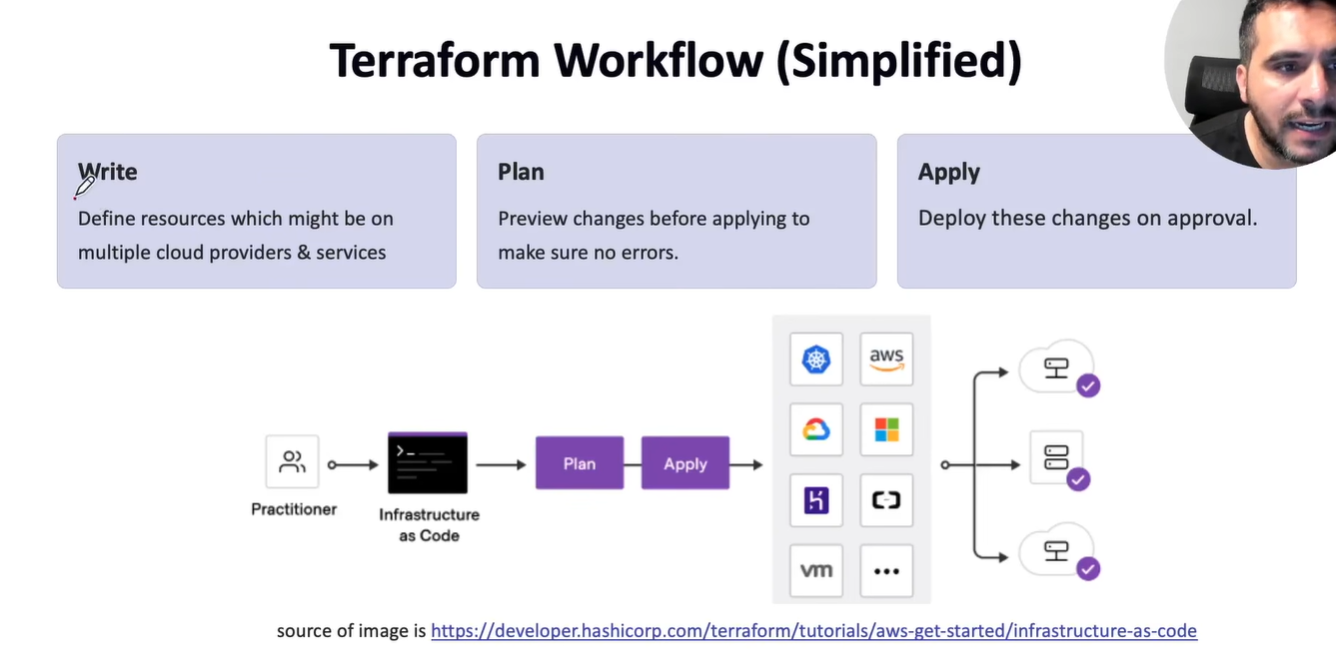



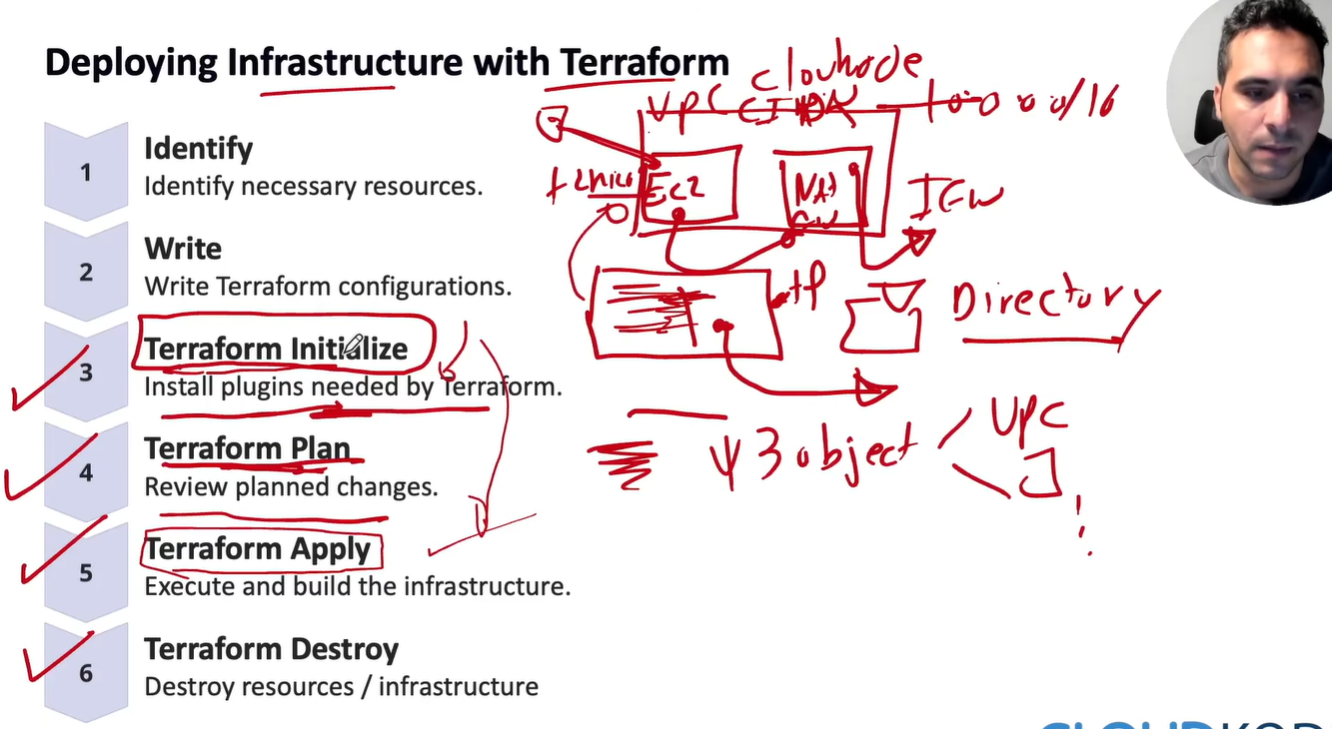


## Terraform Components

Terraform normally works with:

```text
Terraform CLI
     ↓
Provider Plugin
     ↓
Cloud API
     ↓
Infrastructure
```

For AWS:

```text
Terraform
   ↓
AWS Provider
   ↓
AWS APIs
   ↓
EC2 / S3 / RDS / VPC / IAM / EKS
```



---


# 4. Installation and Environment Setup




After installing Terraform, verify:

```bash
terraform version
```

Recommended tools:

```text
Terraform CLI
Git
GitHub
VS Code
AWS CLI
Docker
kubectl
```

Recommended VS Code extension:

```text
HashiCorp Terraform
```

## AWS Authentication

Terraform should normally use AWS credentials already configured in your environment.

Example:

```bash
aws configure
```

Or use temporary/federated credentials where available.

Test AWS access:

```bash
aws sts get-caller-identity
```

Avoid hard-coding AWS credentials in Terraform files.

---



# 5. HCL Fundamentals



Terraform configuration uses **HashiCorp Configuration Language (HCL)**.

Terraform files normally use:

```text
.tf
```

Example project:

```text
terraform-project/
├── main.tf
├── variables.tf
├── outputs.tf
├── providers.tf
└── terraform.tfvars
```

## Blocks

Terraform configuration is mainly organized into blocks.

Example:

```hcl
resource "aws_instance" "server" {
  ami           = "ami-xxxxxxxx"
  instance_type = "t3.micro"
}
```

General syntax:

```hcl
block_type "label1" "label2" {
  argument = value
}
```

## Comments

```hcl
# Single line comment

// Another single line comment

/*
Multi-line
comment
*/
```

## Primitive Types

Terraform supports values such as:

```hcl
name    = "web-server"
count   = 3
enabled = true
```

Main primitive types:

```text
string
number
bool
```

---

# 6. Providers




Providers allow Terraform to communicate with external platforms.

Example AWS provider:

```hcl
terraform {
  required_providers {
    aws = {
      source = "hashicorp/aws"
    }
  }
}

provider "aws" {
  region = "us-east-1"
}
```

Initialize:

```bash
terraform init
```

Terraform downloads the required provider plugins.

## Provider Configuration

Example:

```hcl
provider "aws" {
  region = var.aws_region
}
```

## Multiple Provider Configurations

Aliases can be used:

```hcl
provider "aws" {
  region = "us-east-1"
}

provider "aws" {
  alias  = "eu"
  region = "eu-west-1"
}
```

Resource using the alias:

```hcl
resource "aws_s3_bucket" "eu_bucket" {
  provider = aws.eu
  bucket   = "example-eu-bucket"
}
```

---


# 7. Resources




Resources represent infrastructure objects.

Syntax:

```hcl
resource "provider_resource" "terraform_name" {
}
```

Example:

```hcl
resource "aws_s3_bucket" "logs" {
  bucket = "company-app-logs"
}
```

Reference resource attributes:

```hcl
aws_s3_bucket.logs.id
```

Example:

```hcl
output "bucket_id" {
  value = aws_s3_bucket.logs.id
}
```

---

# 8. Variables




Variables make Terraform code reusable.

Create:

```text
variables.tf
```

Example:

```hcl
variable "instance_type" {
  description = "EC2 instance type"
  type        = string
  default     = "t3.micro"
}
```

Use:

```hcl
resource "aws_instance" "web" {
  instance_type = var.instance_type
}
```

## Variable Types

```hcl
variable "name" {
  type = string
}

variable "replicas" {
  type = number
}

variable "enabled" {
  type = bool
}
```

Collections:

```hcl
variable "availability_zones" {
  type = list(string)
}

variable "tags" {
  type = map(string)
}
```

Objects:

```hcl
variable "server" {
  type = object({
    instance_type = string
    monitoring    = bool
  })
}
```

## terraform.tfvars

Example:

```hcl
aws_region    = "us-east-1"
instance_type = "t3.micro"
environment   = "dev"
```

Terraform automatically loads:

```text
terraform.tfvars
*.auto.tfvars
```

## Command-Line Variables

```bash
terraform apply -var="environment=dev"
```

---



# 9. Outputs



Outputs expose useful information after deployment.

Example:

```hcl
output "instance_public_ip" {
  description = "Public IP of EC2 instance"
  value       = aws_instance.web.public_ip
}
```

View:

```bash
terraform output
```

Specific output:

```bash
terraform output instance_public_ip
```

Outputs are often used for:

- IP addresses
- DNS names
- resource IDs
- database endpoints
- VPC IDs
- load balancer URLs

---


# 10. Locals




Local values reduce duplication.

```hcl
locals {
  environment = "dev"

  common_tags = {
    Environment = local.environment
    ManagedBy   = "Terraform"
    Project     = "MyApp"
  }
}
```

Usage:

```hcl
resource "aws_s3_bucket" "app" {
  bucket = "my-app-storage"

  tags = local.common_tags
}
```

Variables are external inputs.

Locals are internal computed/reusable values.

---




# 11. Data Sources



A data source reads existing infrastructure.

Example:

```hcl
data "aws_caller_identity" "current" {}
```

Use:

```hcl
output "account_id" {
  value = data.aws_caller_identity.current.account_id
}
```

Example AMI lookup:

```hcl
data "aws_ami" "amazon_linux" {
  most_recent = true
  owners      = ["amazon"]

  filter {
    name   = "name"
    values = ["al2023-ami-*-x86_64"]
  }
}
```

Then:

```hcl
resource "aws_instance" "web" {
  ami           = data.aws_ami.amazon_linux.id
  instance_type = "t3.micro"
}
```

---



# 12. Terraform Commands



## Initialize

```bash
terraform init
```

Downloads providers and initializes backend configuration.

## Format

```bash
terraform fmt
```

Format recursively:

```bash
terraform fmt -recursive
```

## Validate

```bash
terraform validate
```

Checks configuration syntax and internal consistency.

## Plan

```bash
terraform plan
```

Terraform shows intended changes.

Common symbols:

```text
+ create
~ update
- destroy
-/+ replace
```

Save a plan:

```bash
terraform plan -out=tfplan
```

Apply saved plan:

```bash
terraform apply tfplan
```

## Apply

```bash
terraform apply
```

Auto approve:

```bash
terraform apply -auto-approve
```

Use auto-approve carefully, especially in production.

## Destroy

```bash
terraform destroy
```

## Show

```bash
terraform show
```

## State

```bash
terraform state list
```

## Output

```bash
terraform output
```

---


# 13. Terraform State



Terraform keeps track of managed resources using a **state file**.

Default:

```text
terraform.tfstate
```

State maps Terraform configuration to real infrastructure.

Example relationship:

```text
aws_instance.web
       ↓
Terraform State
       ↓
EC2 Instance i-0123456789
```

Terraform state contains important infrastructure information.

Do not casually modify it manually.

## Important State Commands

List:

```bash
terraform state list
```

Show:

```bash
terraform state show aws_instance.web
```

Move:

```bash
terraform state mv OLD NEW
```

Remove from state:

```bash
terraform state rm aws_instance.web
```

Removing from state does **not necessarily delete the real cloud resource**. It tells Terraform to stop tracking it.

---




# 14. Remote State and State Locking



Local state is not suitable for most team environments.

Problems:

```text
Developer A → terraform.tfstate
Developer B → another terraform.tfstate
```

This can create conflicts.

Remote state provides a shared source of truth.

Common backend options include:

- Terraform Cloud / HCP Terraform
- Amazon S3
- Azure Storage
- Google Cloud Storage
- other supported backends

Conceptually:

```text
Developer
   ↓
Terraform
   ↓
Remote Backend
   ↓
Shared State
```

## Example S3 Backend

```hcl
terraform {
  backend "s3" {
    bucket = "company-terraform-state"
    key    = "prod/network/terraform.tfstate"
    region = "us-east-1"
  }
}
```

Then:

```bash
terraform init
```

Backend settings should be designed carefully for:

- encryption
- access control
- versioning
- state locking
- disaster recovery

Never store sensitive state in a public bucket.

---


# 15. Resource Dependencies




Terraform automatically detects many dependencies.

Example:

```hcl
resource "aws_subnet" "public" {
  vpc_id     = aws_vpc.main.id
  cidr_block = "10.0.1.0/24"
}
```

Terraform understands:

```text
VPC must exist
      ↓
Subnet can be created
```

## Explicit Dependency

```hcl
depends_on = [
  aws_internet_gateway.main
]
```

Use `depends_on` only when the dependency cannot be inferred naturally.

---



# 16. Meta-Arguments



Important Terraform meta-arguments include:

- `count`
- `for_each`
- `depends_on`
- `provider`
- `lifecycle`

## count

```hcl
resource "aws_instance" "server" {
  count = 3

  ami           = data.aws_ami.amazon_linux.id
  instance_type = "t3.micro"
}
```

References:

```hcl
aws_instance.server[0].id
```

## for_each

```hcl
variable "instances" {
  default = {
    web = "t3.micro"
    api = "t3.small"
  }
}

resource "aws_instance" "server" {
  for_each = var.instances

  ami           = data.aws_ami.amazon_linux.id
  instance_type = each.value

  tags = {
    Name = each.key
  }
}
```

References:

```hcl
aws_instance.server["web"].id
```

### count vs for_each

Use `count` when instances are naturally indexed.

Use `for_each` when instances have stable meaningful keys.

---




# 17. Expressions, Functions, and Collections



## Conditional Expression

```hcl
instance_type = var.environment == "prod" ? "t3.large" : "t3.micro"
```

## List

```hcl
availability_zones = [
  "us-east-1a",
  "us-east-1b"
]
```

Access:

```hcl
var.availability_zones[0]
```

## Map

```hcl
instance_types = {
  dev  = "t3.micro"
  prod = "t3.large"
}
```

Access:

```hcl
var.instance_types["prod"]
```

## Useful Functions

```hcl
length(var.subnets)
```

```hcl
upper("production")
```

```hcl
lower("PRODUCTION")
```

```hcl
join(",", var.availability_zones)
```

```hcl
lookup(var.instance_types, "prod", "t3.micro")
```

```hcl
merge(local.common_tags, {
  Name = "web-server"
})
```

```hcl
cidrsubnet("10.0.0.0/16", 8, 1)
```

---


# 18. Dynamic Blocks



Dynamic blocks generate nested configuration.

Example:

```hcl
variable "ingress_rules" {
  default = [
    {
      port = 80
      cidr = "0.0.0.0/0"
    },
    {
      port = 443
      cidr = "0.0.0.0/0"
    }
  ]
}

resource "aws_security_group" "web" {
  name = "web-sg"

  dynamic "ingress" {
    for_each = var.ingress_rules

    content {
      from_port   = ingress.value.port
      to_port     = ingress.value.port
      protocol    = "tcp"
      cidr_blocks = [ingress.value.cidr]
    }
  }
}
```

Use dynamic blocks only when repeated nested blocks genuinely improve maintainability.

---



# 19. Provisioners



Provisioners can execute scripts.

Example:

```hcl
provisioner "local-exec" {
  command = "echo deployment-complete"
}
```

Remote provisioners also exist.

However, provisioners should normally be treated as a **last resort**.

Prefer:

- cloud-init
- EC2 user data
- configuration management
- image baking
- containerization
- dedicated deployment tools

Terraform should primarily manage infrastructure lifecycle.


## Terraform Provisioning vs Configuration Management

Terraform is primarily an **Infrastructure Provisioning / Infrastructure as Code (IaC)** tool.


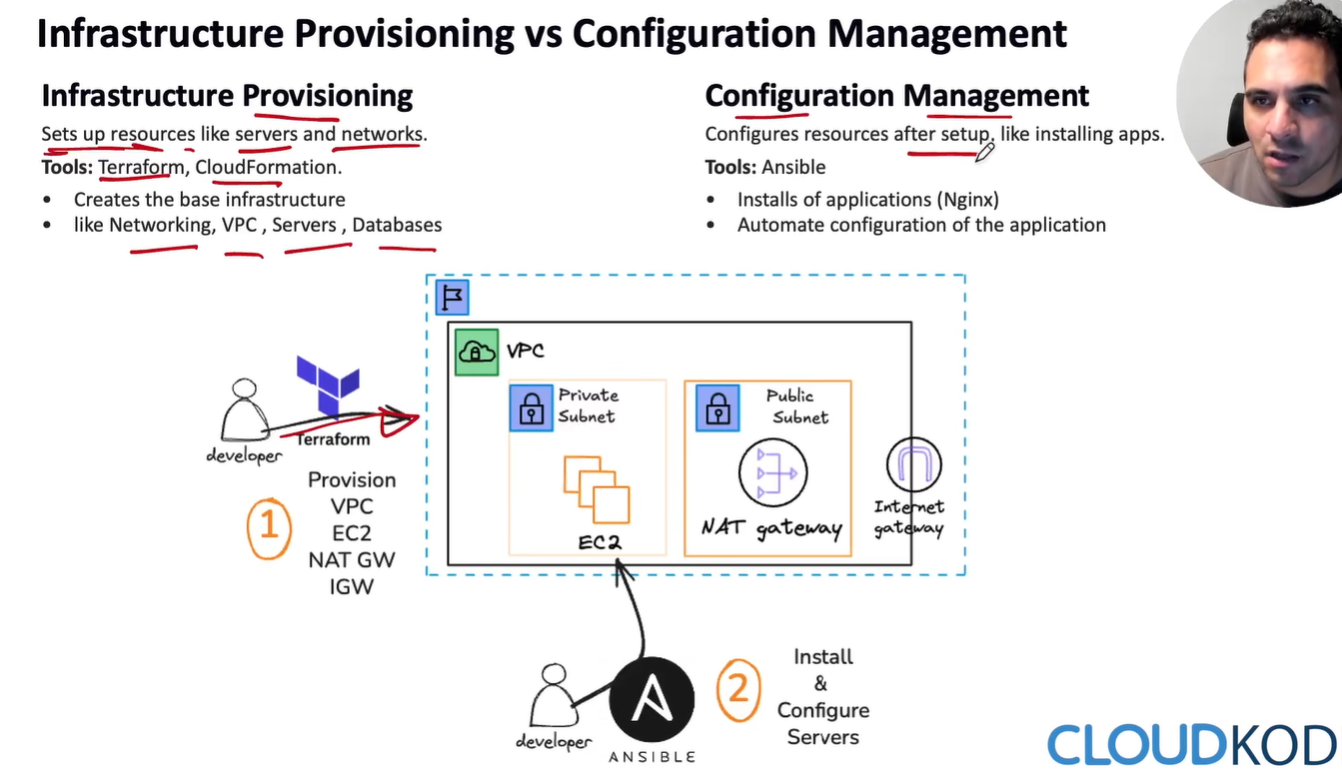


### Infrastructure Provisioning

Terraform creates and manages infrastructure resources such as:

- VPCs
- Subnets
- EC2 instances
- Load Balancers
- RDS databases
- S3 buckets
- IAM roles
- Kubernetes clusters

Example:

```text
Terraform
    ↓
AWS API
    ↓
Create EC2 Instance
```


## Configuration Management

Configuration-management tools configure the operating system and software **inside** an already-created server.

Examples:

- Ansible
- Puppet
- Chef
- cloud-init
- EC2 User Data

Example:

```text
Terraform
    ↓
Create EC2
    ↓
Ansible / User Data
    ↓
Install Nginx
Configure Application
Start Services
```

## Terraform Provisioners

Terraform provisioners allow scripts or commands to run during resource creation or destruction.

Example:

```hcl
provisioner "local-exec" {
  command = "echo deployment-complete"
}
```


Common types include:

- `local-exec` → runs a command on the machine running Terraform.
- `remote-exec` → runs commands on the remote resource, typically through SSH or WinRM.

Provisioners therefore provide some **configuration-management-like capability**, but they are not Terraform's primary purpose.

> **Best Practice:** Treat Terraform provisioners as a **last resort**. Use Terraform for infrastructure provisioning and tools such as **cloud-init, EC2 User Data, Ansible, image baking, containers, or deployment systems** for application and server configuration.

The clean conceptual separation is:

```text
Terraform
Infrastructure Provisioning
        ↓
Creates Server
        ↓
Ansible / cloud-init / User Data
Configuration Management
        ↓
Server Ready for Application
```

---


# 20. Terraform Modules




Modules are one of Terraform's most important concepts.

A module is a reusable Terraform configuration.

Example:

```text
modules/
└── vpc/
    ├── main.tf
    ├── variables.tf
    └── outputs.tf
```

Root configuration:

```text
main.tf
variables.tf
outputs.tf
modules/
```

Call module:

```hcl
module "network" {
  source = "./modules/vpc"

  vpc_cidr = "10.0.0.0/16"
}
```

Module output:

```hcl
output "vpc_id" {
  value = module.network.vpc_id
}
```

## Why Modules Matter

Modules provide:

- reusability
- consistency
- abstraction
- standardization
- easier maintenance
- shared infrastructure components

Typical modules:

```text
vpc
ec2
ecs
eks
rds
alb
iam
s3
monitoring
```

## Module Structure

Recommended:

```text
modules/vpc/
├── main.tf
├── variables.tf
├── outputs.tf
├── versions.tf
└── README.md
```

---


# 21. Terraform Workspaces



Terraform workspaces allow separate state instances for the same configuration.

List:

```bash
terraform workspace list
```

Create:

```bash
terraform workspace new dev
```

Switch:

```bash
terraform workspace select dev
```

Current:

```bash
terraform workspace show
```

Example:

```hcl
tags = {
  Environment = terraform.workspace
}
```

Workspaces can be useful, but for complex production environments many teams prefer separate directories, repositories, or backend/state configurations.

Example:

```text
environments/
├── dev/
├── staging/
└── prod/
```

---


# 22. Lifecycle Management




Terraform provides lifecycle rules.

Example:

```hcl
resource "aws_instance" "web" {
  ami           = data.aws_ami.amazon_linux.id
  instance_type = "t3.micro"

  lifecycle {
    create_before_destroy = true
  }
}
```

## create_before_destroy

Create replacement before deleting old resource.

## prevent_destroy

```hcl
lifecycle {
  prevent_destroy = true
}
```

Useful for critical resources such as production databases.

## ignore_changes

```hcl
lifecycle {
  ignore_changes = [
    tags
  ]
}
```

Use carefully because Terraform will intentionally ignore specified drift.

---



# 23. Importing Existing Infrastructure



Terraform can begin managing resources that were created manually.

Typical workflow:

1. Define the Terraform resource.
2. Import the existing object.
3. Run `terraform plan`.
4. Reconcile configuration until the plan is correct.

Example:

```hcl
resource "aws_s3_bucket" "existing" {
  bucket = "existing-company-bucket"
}
```

Import:

```bash
terraform import aws_s3_bucket.existing existing-company-bucket
```

Modern Terraform also supports declarative import workflows in configuration.

After import, always inspect:

```bash
terraform plan
```

Importing attaches existing infrastructure to Terraform state; it does not magically produce perfect configuration for every resource.

---



# 24. Managing Sensitive Data



Never hard-code secrets:

```hcl
password = "MySecretPassword123"
```

Avoid committing:

```text
AWS access keys
database passwords
private keys
API tokens
sensitive tfvars
state files containing sensitive values
```

## Sensitive Variables

```hcl
variable "db_password" {
  type      = string
  sensitive = true
}
```

Sensitive output:

```hcl
output "password" {
  value     = var.db_password
  sensitive = true
}
```

Marking data as sensitive mainly prevents normal display in Terraform output. Sensitive values can still exist in state.

Prefer secret managers such as:

- AWS Secrets Manager
- AWS Systems Manager Parameter Store
- HCP Vault
- CI/CD encrypted secrets

---


# 25. Terraform with AWS



A basic AWS Terraform project:

```text
aws-project/
├── main.tf
├── providers.tf
├── variables.tf
├── outputs.tf
└── terraform.tfvars
```

## providers.tf

```hcl
terraform {
  required_providers {
    aws = {
      source = "hashicorp/aws"
    }
  }
}

provider "aws" {
  region = var.aws_region
}
```

## variables.tf

```hcl
variable "aws_region" {
  type    = string
  default = "us-east-1"
}
```

## main.tf

```hcl
data "aws_caller_identity" "current" {}

output "account_id" {
  value = data.aws_caller_identity.current.account_id
}
```

Run:

```bash
terraform init
terraform fmt
terraform validate
terraform plan
terraform apply
```

---

# 26. AWS Networking Project





Goal:

```text
VPC
├── Public Subnet
├── Private Subnet
├── Internet Gateway
├── Route Table
└── Security Groups
```

## VPC

```hcl
resource "aws_vpc" "main" {
  cidr_block           = "10.0.0.0/16"
  enable_dns_support   = true
  enable_dns_hostnames = true

  tags = {
    Name = "main-vpc"
  }
}
```

## Public Subnet

```hcl
resource "aws_subnet" "public" {
  vpc_id                  = aws_vpc.main.id
  cidr_block              = "10.0.1.0/24"
  map_public_ip_on_launch = true

  tags = {
    Name = "public-subnet"
  }
}
```

## Private Subnet

```hcl
resource "aws_subnet" "private" {
  vpc_id     = aws_vpc.main.id
  cidr_block = "10.0.2.0/24"

  tags = {
    Name = "private-subnet"
  }
}
```

## Internet Gateway

```hcl
resource "aws_internet_gateway" "main" {
  vpc_id = aws_vpc.main.id
}
```

## Route Table

```hcl
resource "aws_route_table" "public" {
  vpc_id = aws_vpc.main.id

  route {
    cidr_block = "0.0.0.0/0"
    gateway_id = aws_internet_gateway.main.id
  }
}
```

## Association

```hcl
resource "aws_route_table_association" "public" {
  subnet_id      = aws_subnet.public.id
  route_table_id = aws_route_table.public.id
}
```

---


# 27. AWS EC2 Project



Architecture:

```text
Internet
   ↓
Internet Gateway
   ↓
Public Subnet
   ↓
EC2
```

Security group:

```hcl
resource "aws_security_group" "web" {
  name   = "web-sg"
  vpc_id = aws_vpc.main.id

  ingress {
    from_port   = 80
    to_port     = 80
    protocol    = "tcp"
    cidr_blocks = ["0.0.0.0/0"]
  }

  egress {
    from_port   = 0
    to_port     = 0
    protocol    = "-1"
    cidr_blocks = ["0.0.0.0/0"]
  }
}
```

EC2:

```hcl
data "aws_ami" "amazon_linux" {
  most_recent = true
  owners      = ["amazon"]

  filter {
    name   = "name"
    values = ["al2023-ami-*-x86_64"]
  }
}

resource "aws_instance" "web" {
  ami                         = data.aws_ami.amazon_linux.id
  instance_type               = "t3.micro"
  subnet_id                   = aws_subnet.public.id
  vpc_security_group_ids      = [aws_security_group.web.id]
  associate_public_ip_address = true

  user_data = <<-EOF
    #!/bin/bash
    dnf install -y httpd
    systemctl enable --now httpd
    echo "<h1>Terraform Web Server</h1>" > /var/www/html/index.html
  EOF

  tags = {
    Name = "terraform-web"
  }
}
```

Output:

```hcl
output "public_ip" {
  value = aws_instance.web.public_ip
}
```

---


# 28. AWS Load Balancer and Auto Scaling




Production web architecture:

```text
Internet
   ↓
Application Load Balancer
   ↓
Target Group
   ↓
Auto Scaling Group
   ↓
EC2 Instances
```

Terraform resources commonly involved:

```text
aws_lb
aws_lb_target_group
aws_lb_listener
aws_launch_template
aws_autoscaling_group
aws_security_group
aws_subnet
```

Key concept:

Terraform provisions infrastructure.

Auto Scaling controls runtime instance count according to configured policy.

---


# 29. AWS RDS




Typical architecture:

```text
Application
    ↓
Private Network
    ↓
RDS PostgreSQL
```

Example subnet group:

```hcl
resource "aws_db_subnet_group" "main" {
  name = "main-db-subnet-group"

  subnet_ids = [
    aws_subnet.private_a.id,
    aws_subnet.private_b.id
  ]
}
```

Example RDS:

```hcl
resource "aws_db_instance" "postgres" {
  identifier             = "app-db"
  engine                 = "postgres"
  instance_class         = "db.t3.micro"
  allocated_storage      = 20
  username               = var.db_username
  password               = var.db_password
  db_subnet_group_name   = aws_db_subnet_group.main.name
  publicly_accessible    = false
  skip_final_snapshot    = true
}
```

For production, review:

- backups
- Multi-AZ
- encryption
- deletion protection
- final snapshots
- monitoring
- secrets management
- maintenance windows

---

# 30. AWS S3




Create bucket:

```hcl
resource "aws_s3_bucket" "app" {
  bucket = "example-application-storage"
}
```

Versioning:

```hcl
resource "aws_s3_bucket_versioning" "app" {
  bucket = aws_s3_bucket.app.id

  versioning_configuration {
    status = "Enabled"
  }
}
```

Block public access:

```hcl
resource "aws_s3_bucket_public_access_block" "app" {
  bucket = aws_s3_bucket.app.id

  block_public_acls       = true
  block_public_policy     = true
  ignore_public_acls      = true
  restrict_public_buckets = true
}
```

---


# 31. AWS IAM




Example IAM role:

```hcl
resource "aws_iam_role" "app" {
  name = "application-role"

  assume_role_policy = jsonencode({
    Version = "2012-10-17"
    Statement = [
      {
        Effect = "Allow"
        Principal = {
          Service = "ec2.amazonaws.com"
        }
        Action = "sts:AssumeRole"
      }
    ]
  })
}
```

Terraform can manage:

- IAM users
- roles
- policies
- instance profiles
- trust policies
- permissions

Security principle:

```text
Least Privilege
```

Grant only the permissions required.

---


# 32. Terraform and Docker




Terraform can manage Docker resources through a Docker provider.

Concept:

```text
Terraform
   ↓
Docker Provider
   ↓
Docker Engine
   ↓
Images / Containers / Networks
```

For normal application deployment, Docker Compose or container orchestrators may often be more appropriate.

Terraform is most useful when Docker resources are part of a broader infrastructure workflow.

---



# 33. Terraform and Kubernetes






Terraform can provision:

```text
EKS cluster
VPC
subnets
IAM roles
node groups
security groups
supporting AWS infrastructure
```

Architecture:

```text
Terraform
   ↓
AWS
   ↓
EKS Cluster
   ↓
Kubernetes
   ↓
Applications
```

Terraform can also interact with Kubernetes resources through providers, but teams frequently separate:

```text
Infrastructure provisioning → Terraform
Application deployment      → Helm / Argo CD / Flux / kubectl
```

That separation often improves operational clarity.

---


# 34. Terraform in CI/CD



Typical CI/CD pipeline:

```text
Developer
   ↓
Git Push
   ↓
CI Pipeline
   ↓
terraform fmt
   ↓
terraform validate
   ↓
terraform plan
   ↓
Review / Approval
   ↓
terraform apply
```

Recommended pipeline stages:

```text
1. Checkout
2. Configure cloud authentication
3. Setup Terraform
4. terraform init
5. terraform fmt -check
6. terraform validate
7. terraform plan
8. Security scan
9. Approval
10. terraform apply
```

Production environments should generally require stronger controls than development environments.

---



# 35. Terraform with GitHub Actions



Example conceptual workflow:

```yaml
name: Terraform

on:
  pull_request:
  push:
    branches:
      - main
```

Typical jobs:

```text
Pull Request:
terraform init
terraform fmt -check
terraform validate
terraform plan

Main branch:
terraform init
terraform plan
terraform apply
```

A simplified workflow:

```yaml
name: Terraform CI

on:
  pull_request:
  push:
    branches:
      - main

jobs:
  terraform:
    runs-on: ubuntu-latest

    permissions:
      contents: read

    steps:
      - name: Checkout
        uses: actions/checkout@v4

      - name: Setup Terraform
        uses: hashicorp/setup-terraform@v3

      - name: Terraform Init
        run: terraform init

      - name: Terraform Format
        run: terraform fmt -check -recursive

      - name: Terraform Validate
        run: terraform validate

      - name: Terraform Plan
        run: terraform plan
```

For AWS authentication, prefer secure temporary credentials and workload identity mechanisms such as GitHub OIDC rather than storing long-lived cloud keys whenever possible.

Concept:

```text
GitHub Actions
      ↓
OIDC
      ↓
AWS IAM Role
      ↓
Temporary Credentials
      ↓
Terraform
```

---

# 36. Repository Structure




Small project:

```text
terraform/
├── main.tf
├── variables.tf
├── outputs.tf
├── providers.tf
└── terraform.tfvars
```

Larger project:

```text
terraform/
├── modules/
│   ├── vpc/
│   ├── ec2/
│   ├── rds/
│   ├── alb/
│   └── s3/
│
├── environments/
│   ├── dev/
│   ├── staging/
│   └── prod/
│
└── README.md
```

Example environment:

```text
environments/dev/
├── main.tf
├── providers.tf
├── variables.tf
├── outputs.tf
└── terraform.tfvars
```

---

# 37. Testing and Validation




Minimum checks:

```bash
terraform fmt -check -recursive
terraform validate
terraform plan
```

Useful categories of Terraform testing:

```text
Syntax validation
Formatting validation
Plan inspection
Static analysis
Policy checks
Security scanning
Integration testing
Terratest
Terraform native tests
```

Example CI validation:

```bash
terraform init -backend=false
terraform validate
```

For configurations requiring backend/provider access, adapt validation accordingly.

---



# 38. Security Best Practices





## Never Commit Secrets

Add sensitive local files to `.gitignore`.

Example:

```gitignore
.terraform/
*.tfstate
*.tfstate.*
crash.log
*.tfvars
*.tfplan
.env
```

Be careful: not every `*.tfvars` file is secret, but many teams exclude environment-specific secret-bearing variable files.

## Avoid Long-Lived Credentials

Prefer:

```text
AWS IAM roles
OIDC
temporary credentials
secret managers
```

instead of:

```text
hard-coded access keys
```

## Protect Terraform State

State may contain:

- resource identifiers
- network information
- generated values
- passwords
- secrets

Protect with:

```text
encryption
access controls
versioning
locking
audit logs
```

## Least Privilege

Terraform execution identities should have only required permissions.

## Security Scanners

Common categories of tooling include:

```text
Terraform linting
IaC security scanning
policy-as-code
cloud security checks
```

Examples often used in the ecosystem include:

- TFLint
- Checkov
- tfsec
- Terrascan

---



# 39. Troubleshooting



## Error: Provider Not Installed

Run:

```bash
terraform init
```

## Error: Configuration Changed

Run:

```bash
terraform plan
```

Inspect drift.

## Error: Resource Already Exists

Possible solutions:

```text
Import the existing resource
Rename resource
Remove conflicting object
Correct configuration
```

## Authentication Failure

Check:

```bash
aws sts get-caller-identity
```

Verify:

```text
credentials
region
role permissions
session expiration
```

## State Lock Error

Do not immediately force-unlock.

First verify that no other Terraform process is running.

Then, only when safe, use the appropriate backend recovery procedure.

## Invalid Reference

Example mistake:

```hcl
aws_instance.server.ip
```

Correct attribute may be:

```hcl
aws_instance.server.public_ip
```

Check provider documentation.

## Unsupported Argument

The provider schema may have changed or the argument may belong to a different resource/block.

Check:

```bash
terraform validate
```

and the provider documentation.

---




# 40. Common Interview Questions



## What is Terraform?

Terraform is a declarative Infrastructure as Code tool used to provision and manage infrastructure through providers.

## What is Terraform state?

State stores Terraform's mapping between configuration and managed infrastructure.

## What is a provider?

A provider is a plugin Terraform uses to communicate with an external API such as AWS, Azure, Kubernetes, or GitHub.

## What is a module?

A reusable collection of Terraform configuration files.

## `terraform plan` vs `terraform apply`

```text
plan  → preview proposed changes
apply → execute proposed changes
```

## `count` vs `for_each`

```text
count    → index-based repetition
for_each → key-based repetition
```

## Variable vs Local

```text
variable → external input
local    → internal reusable/computed value
```

## Resource vs Data Source

```text
resource    → manages infrastructure
data source → reads infrastructure/data
```

## Local State vs Remote State

```text
Local  → stored on developer machine
Remote → stored in shared backend
```

## Why State Locking?

To prevent multiple Terraform executions from modifying the same state concurrently.

## Terraform vs Ansible

Terraform focuses mainly on infrastructure provisioning and lifecycle.

Ansible focuses mainly on configuration management and automation.

Example:

```text
Terraform → create EC2
Ansible   → configure software on EC2
```

## Terraform vs CloudFormation

Terraform:

```text
multi-provider ecosystem
HCL
cross-platform workflows
```

CloudFormation:

```text
AWS-native
deep AWS integration
JSON/YAML
```

---

# 41. Hands-On Projects




## Project 1 — EC2 Web Server

Build:

```text
VPC
Subnet
Internet Gateway
Route Table
Security Group
EC2
Apache
```

Skills:

```text
resources
references
data sources
outputs
user data
```

## Project 2 — Highly Available Web Application

Build:

```text
VPC
├── Public Subnet A
├── Public Subnet B
├── Private Subnet A
└── Private Subnet B

Application Load Balancer
Auto Scaling Group
EC2
```

Skills:

```text
multiple AZs
load balancing
launch templates
autoscaling
modules
```

## Project 3 — Three-Tier AWS Architecture

Build:

```text
Internet
   ↓
ALB
   ↓
Application EC2 / ECS
   ↓
RDS PostgreSQL
```

Include:

```text
VPC
public subnets
private application subnets
private database subnets
security groups
NAT or appropriate egress design
RDS
S3
IAM
CloudWatch
```

## Project 4 — Reusable Terraform Modules

Create:

```text
modules/vpc
modules/security-group
modules/ec2
modules/rds
modules/alb
```

Then deploy:

```text
dev
staging
prod
```

## Project 5 — Terraform CI/CD

Use:

```text
GitHub
GitHub Actions
Terraform
AWS
```

Pull request:

```text
fmt
validate
plan
security scan
```

Main branch:

```text
approved apply
```

## Project 6 — AI Backend Infrastructure

Architecture:

```text
Internet
   ↓
Application Load Balancer
   ↓
ECS / EKS / EC2
   ↓
FastAPI
   ↓
PostgreSQL + pgvector
Redis
S3
CloudWatch
```

Terraform manages:

```text
VPC
subnets
IAM
security groups
compute
database
cache
storage
load balancer
DNS
monitoring infrastructure
```

This is especially useful for an AI Platform / RAG / backend engineering portfolio.

---



# 42. Learning Roadmap




## Phase 1 — Terraform Fundamentals

Learn:

```text
IaC
Terraform workflow
providers
resources
variables
outputs
locals
data sources
```

Practice:

```bash
terraform init
terraform fmt
terraform validate
terraform plan
terraform apply
terraform destroy
```

## Phase 2 — HCL

Learn:

```text
strings
numbers
booleans
lists
maps
objects
conditionals
for expressions
functions
```

## Phase 3 — State

Learn:

```text
terraform.tfstate
remote backend
state locking
state commands
state recovery
```

## Phase 4 — AWS

Practice:

```text
VPC
subnets
route tables
internet gateway
NAT design
EC2
security groups
S3
IAM
RDS
ALB
Auto Scaling
```

## Phase 5 — Advanced Terraform

Learn:

```text
modules
for_each
count
dynamic blocks
lifecycle
imports
multiple providers
workspaces
dependency management
```

## Phase 6 — Production Design

Learn:

```text
remote state
environment separation
module versioning
least privilege
secret management
state protection
tagging
naming conventions
cost control
```

## Phase 7 — CI/CD

Learn:

```text
Git
GitHub
GitHub Actions
Terraform plans in PRs
approval gates
OIDC
automated apply
security scanning
```

## Phase 8 — Kubernetes / Platform Engineering

Learn:

```text
Terraform
AWS EKS
IAM
VPC
Helm
Kubernetes
GitOps
monitoring
```

---


# 43. Terraform Command Cheat Sheet





## Setup

```bash
terraform version
terraform init
```

## Formatting

```bash
terraform fmt
terraform fmt -recursive
terraform fmt -check
```

## Validation

```bash
terraform validate
```

## Planning

```bash
terraform plan
terraform plan -out=tfplan
```

## Apply

```bash
terraform apply
terraform apply tfplan
terraform apply -auto-approve
```

## Destroy

```bash
terraform destroy
```

## Outputs

```bash
terraform output
terraform output output_name
```

## State

```bash
terraform state list
terraform state show RESOURCE
terraform state mv OLD NEW
terraform state rm RESOURCE
```

## Workspaces

```bash
terraform workspace list
terraform workspace new dev
terraform workspace select dev
terraform workspace show
```

## Import

```bash
terraform import RESOURCE_ADDRESS RESOURCE_ID
```

## Show

```bash
terraform show
terraform show tfplan
```

## Console

```bash
terraform console
```

The console is useful for testing expressions and functions.

---


# 44. Final Best Practices





1. Store Terraform code in Git.
2. Use remote state for team environments.
3. Protect state with strong access controls and encryption.
4. Use state locking where supported.
5. Never hard-code cloud credentials.
6. Prefer temporary credentials and IAM roles.
7. Use modules for reusable infrastructure.
8. Keep modules focused and composable.
9. Use variables for environment-specific input.
10. Use locals to reduce repeated expressions.
11. Use outputs only for useful integration data.
12. Run `terraform fmt` before committing.
13. Run `terraform validate` in CI.
14. Review every `terraform plan`.
15. Avoid blind `-auto-approve` usage in production.
16. Use pull requests for infrastructure changes.
17. Require approval for sensitive production applies.
18. Use least-privilege IAM.
19. Avoid storing secrets in Git.
20. Treat Terraform state as sensitive data.
21. Use data sources when referencing existing infrastructure.
22. Prefer `for_each` for resources with stable logical keys.
23. Avoid unnecessary `depends_on`.
24. Avoid provisioners when better deployment mechanisms exist.
25. Pin and manage Terraform/provider versions deliberately.
26. Document modules.
27. Apply consistent resource naming and tagging.
28. Separate development, staging, and production state.
29. Monitor cloud cost implications before applying.
30. Always inspect destroy/replacement actions carefully.

---

## Recommended DevOps Learning Sequence

A strong sequence is:

```text
Linux
  ↓
Networking Fundamentals
  ↓
Git + GitHub
  ↓
Docker
  ↓
AWS
  ↓
Terraform
  ↓
GitHub Actions CI/CD
  ↓
Kubernetes
  ↓
Helm
  ↓
Monitoring
  ↓
Prometheus + Grafana
  ↓
Platform Engineering / SRE
```

Terraform connects many of these skills because it automates the infrastructure where applications, containers, databases, CI/CD runners, Kubernetes clusters, and observability services operate.

---

## Suggested 14-Day Terraform Study Plan

| Day | Topic | Practice |
|---|---|---|
| 1 | IaC + Terraform architecture | Install Terraform, create first configuration |
| 2 | Providers + Resources | Create AWS resource |
| 3 | Variables + Outputs | Parameterize EC2 |
| 4 | Locals + Data Sources | Dynamic AMI lookup |
| 5 | State | Inspect and manipulate state safely |
| 6 | Remote State | Configure shared backend |
| 7 | VPC | Build VPC, subnets, routes |
| 8 | EC2 | Deploy web server |
| 9 | `count` + `for_each` | Deploy multiple resources |
| 10 | Modules | Convert VPC into reusable module |
| 11 | RDS + S3 + IAM | Build application dependencies |
| 12 | ALB + Auto Scaling | Build HA architecture |
| 13 | GitHub Actions | Validate and plan from CI |
| 14 | Final Project | Deploy full three-tier infrastructure |

---

## Final Capstone

Build this architecture entirely with Terraform:

```text
                    Internet
                       │
                       ▼
                 Route 53 / DNS
                       │
                       ▼
              Application Load Balancer
                       │
          ┌────────────┴────────────┐
          ▼                         ▼
     Private App A              Private App B
     ECS / EC2                  ECS / EC2
          │                         │
          └────────────┬────────────┘
                       ▼
               PostgreSQL / RDS
                       │
               Redis / Cache
                       │
                      S3

Supporting Infrastructure:
- VPC
- 2+ Availability Zones
- public subnets
- private application subnets
- private database subnets
- IAM roles
- security groups
- monitoring
- remote Terraform state
- GitHub Actions
- OIDC authentication
```

Repository:

```text
terraform-aws-platform/
├── .github/
│   └── workflows/
│       └── terraform.yml
│
├── modules/
│   ├── vpc/
│   ├── alb/
│   ├── compute/
│   ├── rds/
│   ├── redis/
│   └── s3/
│
├── environments/
│   ├── dev/
│   ├── staging/
│   └── prod/
│
├── .gitignore
└── README.md
```

A project at this level demonstrates practical knowledge of:

```text
Terraform
AWS
Infrastructure as Code
Networking
IAM
Compute
Databases
Load Balancing
State Management
Modules
CI/CD
GitHub Actions
Cloud Security
Platform Engineering
```

---

## End Goal

After completing this material, you should be able to:

- Read and write Terraform HCL.
- Provision AWS infrastructure from code.
- Understand Terraform state and remote state.
- Build reusable modules.
- Manage multiple environments.
- Provision VPC, EC2, S3, IAM, RDS, ALB, and Auto Scaling infrastructure.
- Integrate Terraform with GitHub Actions.
- Protect infrastructure state and credentials.
- Review plans safely.
- Import existing resources.
- Troubleshoot common Terraform errors.
- Design production-oriented Infrastructure as Code repositories.
- Use Terraform as part of DevOps, Cloud Engineering, Platform Engineering, and AI Platform projects.
